In [ ]:
# ==========================================
# DAY 1 & 2: SETUP, LOADING & CLEANING
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Loading the Dataset directly from UCI URL
# This avoids manual file uploads. I use the raw processed Cleveland data.
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

# Define column names (cuz the raw file doesn't have headers)
column_names = [
    "age", "gender", "cp", "trestbps", "chol", "fbs",
    "restecg", "thalach", "exang", "oldpeak",
    "slope", "ca", "thal", "target"
]

# Read the data
print("Loading dataset...")
df = pd.read_csv(url, names=column_names, na_values="?")

# 2. Basic Inspection
print(f"Dataset Shape: {df.shape}")
print("\n--- First 5 Rows ---")
display(df.head())

# 3. Data Cleaning (Handling Missing Values)
# The dataset represents missing values with '?' which I converted to NaN above.
print("\n--- Missing Values Count ---")
print(df.isnull().sum())

# Strategy: Drop rows with missing values (since it's only a few rows in 'ca' and 'thal')
df_clean = df.dropna().copy()
print(f"\nNew Shape after dropping missing values: {df_clean.shape}")

# 4. Target Adjustment (Critical Step)
# The original data has 0=Healthy, 1-4=Different levels of heart disease.
# We want Binary Classification: 0=Healthy, 1=Heart Disease.
df_clean['target'] = df_clean['target'].apply(lambda x: 1 if x > 0 else 0)

print("\n--- Target Distribution (0=Healthy, 1=Disease) ---")
print(df_clean['target'].value_counts())

# Save this clean version for later use if needed
# df_clean.to_csv("heart_disease_clean.csv", index=False)
print("\n✅ Day 1 Task Complete: Data Loaded and Cleaned!")

Loading dataset...
Dataset Shape: (303, 14)

--- First 5 Rows ---


,age,gender,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0



--- Missing Values Count ---
age         0
gender      0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

New Shape after dropping missing values: (297, 14)

--- Target Distribution (0=Healthy, 1=Disease) ---
target
0    160
1    137
Name: count, dtype: int64

✅ Day 1 Task Complete: Data Loaded and Cleaned!


/tmp/ipython-input-635951143.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df_clean, ax=ax[0], palette='coolwarm')


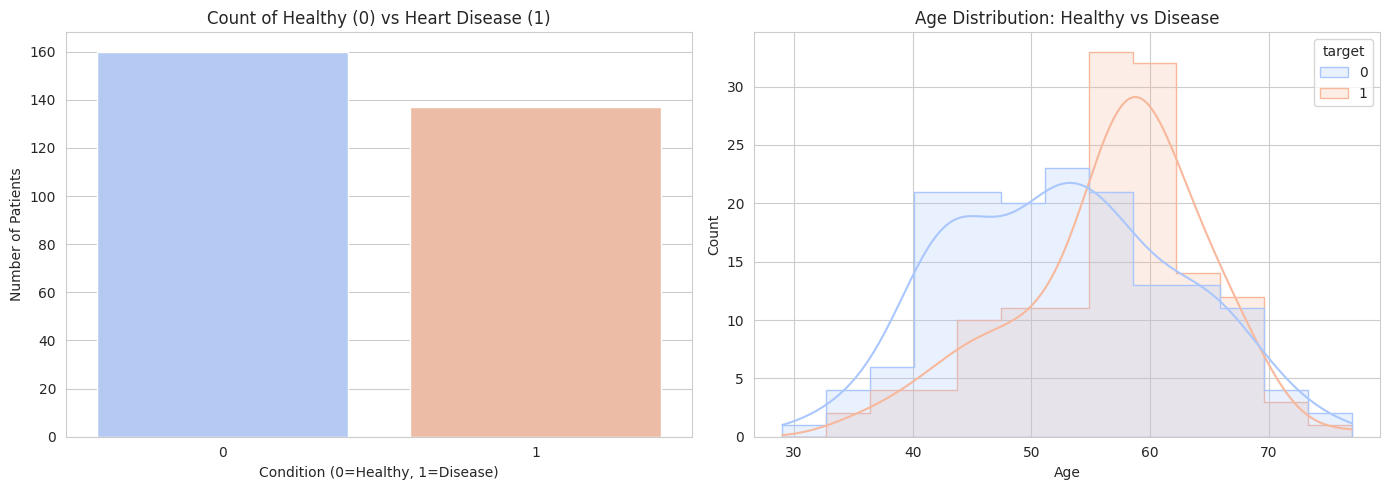

Healthy Patients: 160
Sick Patients: 137
Imbalance Ratio: 1.17 to 1


In [ ]:
# ==========================================
# DAY 3: EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================

# Set the visual style
sns.set_style("whitegrid")

# Create a figure with two side-by-side charts
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# CHART 1: Target Distribution (Healthy vs Disease)
# This shows if our data is balanced or imbalanced
sns.countplot(x='target', data=df_clean, ax=ax[0], palette='coolwarm')
ax[0].set_title('Count of Healthy (0) vs Heart Disease (1)')
ax[0].set_xlabel('Condition (0=Healthy, 1=Disease)')
ax[0].set_ylabel('Number of Patients')

# CHART 2: Age Distribution by Condition
# This shows if older people are more likely to be sick
sns.histplot(data=df_clean, x='age', hue='target', kde=True, element="step", ax=ax[1], palette='coolwarm')
ax[1].set_title('Age Distribution: Healthy vs Disease')
ax[1].set_xlabel('Age')

plt.tight_layout()
plt.show()

# Calculate the exact imbalance for your notes
healthy_count = df_clean['target'].value_counts()[0]
sick_count = df_clean['target'].value_counts()[1]
print(f"Healthy Patients: {healthy_count}")
print(f"Sick Patients: {sick_count}")
print(f"Imbalance Ratio: {healthy_count / sick_count:.2f} to 1")

In [ ]:
# ==========================================
# REVISED DAY 4: BASELINE WITH SCALING
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler # <--- NEW TOOL

# 1. Prepare Data
X = df_clean.drop('target', axis=1)
y = df_clean['target']

# 2. Split into Training and Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale the Data (The Fix for Convergence Warning)
# We teach the scaler on the Training data, then apply it to both Train and Test.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train the "Baseline" Model on Scaled Data
model_baseline = LogisticRegression(max_iter=1000)
model_baseline.fit(X_train_scaled, y_train)

# 5. Predict
y_pred_baseline = model_baseline.predict(X_test_scaled)

# 6. Evaluate
print("--- Baseline Model Results (Scaled) --- The bad model prediction")
print(classification_report(y_test, y_pred_baseline))

# 7. Check Confusion Matrix (To see exactly how many sick people we missed)
cm = confusion_matrix(y_test, y_pred_baseline)
print("\n--- Confusion Matrix ---")
print(f"True Negatives (Healthy predicted Healthy): {cm[0][0]}")
print(f"False Positives (Healthy predicted Sick): {cm[0][1]}")
print(f"False Negatives (Sick predicted Healthy - DANGEROUS): {cm[1][0]}")
print(f"True Positives (Sick predicted Sick): {cm[1][1]}")

--- Baseline Model Results (Scaled) --- The bad model prediction
              precision    recall  f1-score   support

           0       0.89      0.89      0.89        36
           1       0.83      0.83      0.83        24

    accuracy                           0.87        60
   macro avg       0.86      0.86      0.86        60
weighted avg       0.87      0.87      0.87        60


--- Confusion Matrix ---
True Negatives (Healthy predicted Healthy): 32
False Positives (Healthy predicted Sick): 4
False Negatives (Sick predicted Healthy - DANGEROUS): 4
True Positives (Sick predicted Sick): 20


In [ ]:
# ==========================================
# DAY 6-10: SPRINT 2 - SMOTE IMPLEMENTATION
# ==========================================
from imblearn.over_sampling import SMOTE

# 1. Apply SMOTE to the Training Data ONLY
# We generated the scaled training data in the previous step (X_train_scaled)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# Check the new balance
print(f"Original Training Count: {y_train.value_counts().to_dict()}")
print(f"SMOTE Training Count: {y_train_smote.value_counts().to_dict()}")
# (it will show equal numbers now, e.g., 100 vs 100)

# 2. Train a NEW Model on this Balanced Data
model_smote = LogisticRegression(max_iter=1000)
model_smote.fit(X_train_smote, y_train_smote)

# 3. Predict on the ORIGINAL Test Set
# Crucial: We use X_test_scaled (real data), NOT smote data here.
y_pred_smote = model_smote.predict(X_test_scaled)

# 4. Evaluate and Compare
print("\n--- SMOTE Model Results (The 'After' Snapshot) ---")
print(classification_report(y_test, y_pred_smote))

# 5. Confusion Matrix Comparison
cm_smote = confusion_matrix(y_test, y_pred_smote)
print("\n--- SMOTE Confusion Matrix ---")
print(f"True Negatives (Healthy predicted Healthy): {cm_smote[0][0]}")
print(f"False Positives (Healthy predicted Sick): {cm_smote[0][1]}")
print(f"False Negatives (Sick predicted Healthy - DANGEROUS): {cm_smote[1][0]}")
print(f"True Positives (Sick predicted Sick): {cm_smote[1][1]}")

Original Training Count: {0: 124, 1: 113}
SMOTE Training Count: {0: 124, 1: 124}

--- SMOTE Model Results (The 'After' Snapshot) ---
              precision    recall  f1-score   support

           0       0.94      0.86      0.90        36
           1       0.81      0.92      0.86        24

    accuracy                           0.88        60
   macro avg       0.88      0.89      0.88        60
weighted avg       0.89      0.88      0.88        60


--- SMOTE Confusion Matrix ---
True Negatives (Healthy predicted Healthy): 31
False Positives (Healthy predicted Sick): 5
False Negatives (Sick predicted Healthy - DANGEROUS): 2
True Positives (Sick predicted Sick): 22


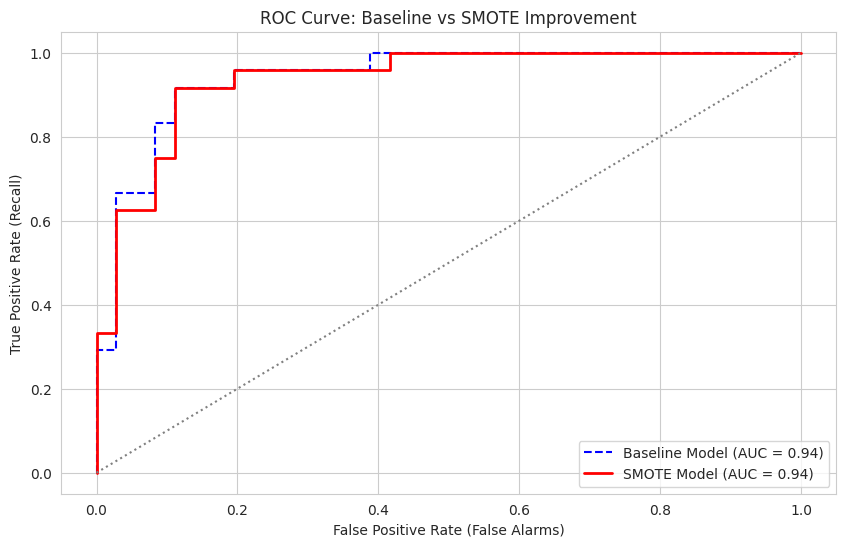

In [ ]:
# ==========================================
# FINAL CODING TASK: ROC-AUC CURVE
# ==========================================
from sklearn.metrics import roc_curve, auc

# 1. Get Probability Scores (Not just 0 or 1, but the % confidence)
# We compare the Baseline vs. SMOTE model
y_prob_baseline = model_baseline.predict_proba(X_test_scaled)[:, 1]
y_prob_smote = model_smote.predict_proba(X_test_scaled)[:, 1]

# 2. Calculate ROC Statistics
fpr_base, tpr_base, _ = roc_curve(y_test, y_prob_baseline)
roc_auc_base = auc(fpr_base, tpr_base)

fpr_smote, tpr_smote, _ = roc_curve(y_test, y_prob_smote)
roc_auc_smote = auc(fpr_smote, tpr_smote)

# 3. Plotting
plt.figure(figsize=(10, 6))

# Plot Baseline
plt.plot(fpr_base, tpr_base, color='blue', linestyle='--',
         label=f'Baseline Model (AUC = {roc_auc_base:.2f})')

# Plot SMOTE (The Hero)
plt.plot(fpr_smote, tpr_smote, color='red', linewidth=2,
         label=f'SMOTE Model (AUC = {roc_auc_smote:.2f})')

# Plot Random Guess Line
plt.plot([0, 1], [0, 1], color='gray', linestyle=':')

# Formatting
plt.xlabel('False Positive Rate (False Alarms)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve: Baseline vs SMOTE Improvement')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()